# Exercises

## Exercise 1: explore filter parameters
---
In this exercises you will explore how different parameters affect the filtering process.
- Import the data form `data/moving_lfp.pickle` (the file is already on your machine if you run the `download_data()` cell in the main lesson)
- Take a few seconds of the data, and filter them in different frequency bands. Plot the resulting singal.
  Fix the central frequency and play with the width of the band, then try to change the central frequency of the band.
- Change the order of the filter, keeping the frequency band fixed. How does the filtered signal change? How does the computing time change? (You can try to quantify the computing time with the jupyter magic command [`%timeit`](https://docs.python.org/3/library/timeit.html) )
- Comment on what you see

## Exercise 2: wavelet transform with real wavelets
---
In this exercises you will explore the difference between real and complex wavelets in the continous wavelet transform.
- Import the data form `data/moving_lfp.pickle`
- Select a period of a few seconds of the signal and compute the spectrogram. 
  Try the wavelet transform with wavelet `mexh` (mexican hat),`gaus` (gaussian) and `morl` (morlet). These are all real wavelets.
- What differences do you see with respect to the spectrum computed with the complex Morlet tranform ? Comment on why do you think this might be the case.

## Exercise 3: REM sleep detection
---
Mammalian sleep is organized in different phases. [Rapid Eye Movement (REM) sleep](https://en.wikipedia.org/wiki/Rapid_eye_movement_sleep) is a well studied phase, with clear markers that make it detectable from LFP data. One of the most used marker is the ratio (or difference) between the oscillatory power in the theta and delta bands in the hippocampus. During REM sleep, the former dominates, in a pattern that resembles active behaviour.  
In this exercise we will use the tools we learned about to detect and inspect the REM and non-REM (nREM) phases of sleep in data recorded from the hippocampus of a sleeping mouse.

- Import the data form `data/sleep_lfp.pickle`
- Compute the instantaneous power in the theta (6-10 Hz) and delta (2-4 Hz) frequency bands, for the whole signal.
- z-score the two power signals (subtract the mean and divide by the standard deviation, you can use `scipy.stats.zscore()`)
- Compute and plot the power difference (`theta_power - delta_power`) for the sleep session.
- Compute the REM (power difference $>0.2$) and nREM (power diffewrence $<0.2$) sleep periods.
- Plot examples of REM vs nREM lfp signals (wideband filtered betw. 1 and 200 Hz to get rid of some of the noise).
- Explore how changing the threshold affects the amount of REM sleep detected.

## Assignment 


In [29]:
import os
import pickle
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pywt import cwt, scale2frequency
from scipy.stats import zscore

sns.set_theme(context="notebook", style="white", font_scale=1.3,
              rc={"axes.spines.top": False, "axes.spines.right": False})

if Path("data/moving_lfp.pickle").exists():
    MODULE_DIR = Path(".")
else:
    MODULE_DIR = Path("01-local_field_potential")

sys.path.insert(0, str((MODULE_DIR / "code").resolve()))
import lfp_functions as lf

def load_lfp(name):
    with open(MODULE_DIR / "data" / name, "rb") as handle:
        data = pickle.load(handle)
    return data["lfp"], data["sampling_rate"]

moving_lfp, moving_sr = load_lfp("moving_lfp.pickle")
sleep_lfp, sleep_sr = load_lfp("sleep_lfp.pickle")

print(f"moving LFP: {len(moving_lfp) / moving_sr:.1f} s sampled at {moving_sr} Hz")
print(f"sleep LFP: {len(sleep_lfp) / sleep_sr:.1f} s sampled at {sleep_sr} Hz")

moving LFP: 600.1 s sampled at 1000.0 Hz
sleep LFP: 1816.6 s sampled at 1000.0 Hz


## Exercise 1 solution

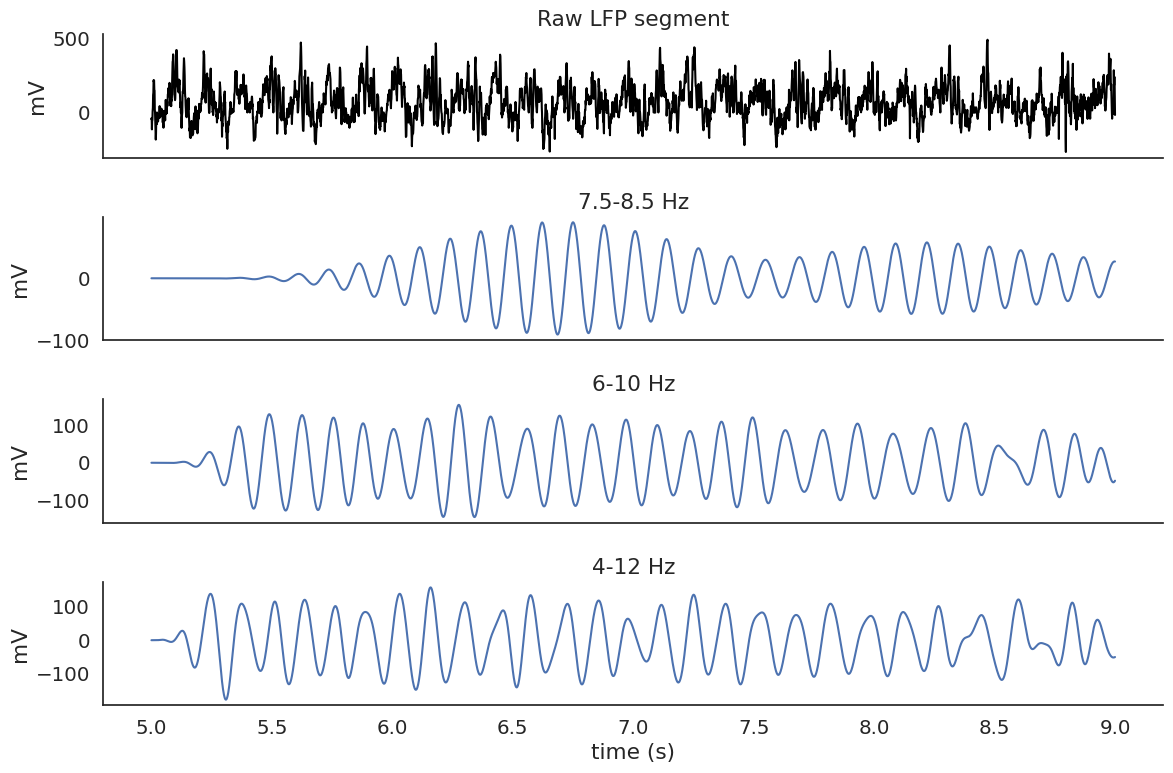

In [30]:
start = 5
duration = 4
stop = start + duration

segment = moving_lfp[int(start * moving_sr):int(stop * moving_sr)]
t = np.arange(len(segment)) / moving_sr + start

fixed_center_bands = {
    "7.5-8.5 Hz": (7.5, 8.5),
    "6-10 Hz": (6, 10),
    "4-12 Hz": (4, 12),
}

fig, axes = plt.subplots(len(fixed_center_bands) + 1, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t, segment, color="black")
axes[0].set_title("Raw LFP segment")
axes[0].set_ylabel("mV")

for ax, (label, (low_f, high_f)) in zip(axes[1:], fixed_center_bands.items()):
    filtered = lf.bandpass_filter(segment, low_f, high_f, sampling_rate=moving_sr, filter_order=5)
    ax.plot(t, filtered)
    ax.set_title(label)
    ax.set_ylabel("mV")

axes[-1].set_xlabel("time (s)")
plt.tight_layout()

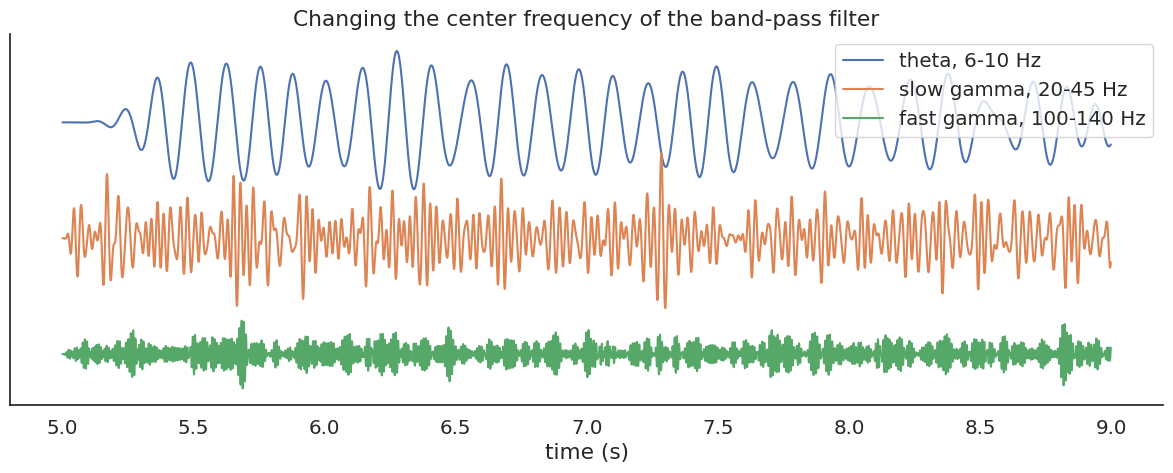

In [31]:
moving_center_bands = {
    "theta, 6-10 Hz": (6, 10),
    "slow gamma, 20-45 Hz": (20, 45),
    "fast gamma, 100-140 Hz": (100, 140),
}

plt.figure(figsize=(12, 5))
offset = 250
for i, (label, (low_f, high_f)) in enumerate(moving_center_bands.items()):
    filtered = lf.bandpass_filter(segment, low_f, high_f, sampling_rate=moving_sr, filter_order=5)
    plt.plot(t, filtered + offset * (len(moving_center_bands) - i - 1), label=label)

plt.title("Changing the center frequency of the band-pass filter")
plt.xlabel("time (s)")
plt.yticks([])
plt.legend(loc="upper right")
plt.tight_layout()

Timing 100 repeated filters of the same 4 s segment:
order  2: 1.589 ms per call
order  5: 1.122 ms per call
order 10: 2.064 ms per call
order 15: 2.499 ms per call


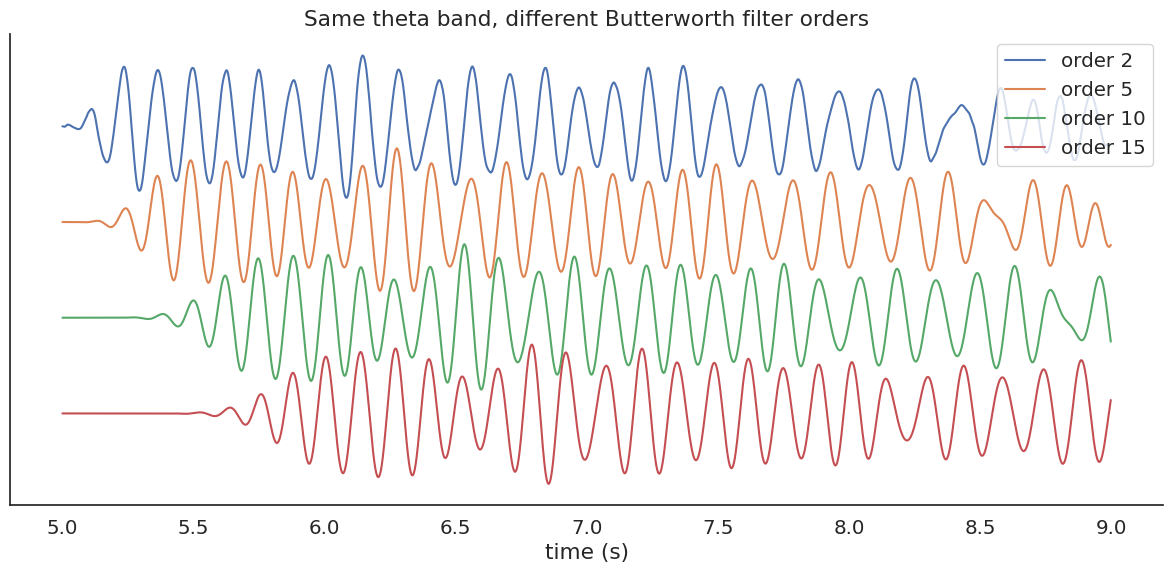

In [32]:
orders = [2, 5, 10, 15]
band = (6, 10)

plt.figure(figsize=(12, 6))
for i, order in enumerate(orders):
    filtered = lf.bandpass_filter(segment, *band, sampling_rate=moving_sr, filter_order=order)
    plt.plot(t, filtered + 200 * (len(orders) - i - 1), label=f"order {order}")

plt.title("Same theta band, different Butterworth filter orders")
plt.xlabel("time (s)")
plt.yticks([])
plt.legend(loc="upper right")
plt.tight_layout()

print("Timing 100 repeated filters of the same 4 s segment:")
for order in orders:
    tic = time.perf_counter()
    for _ in range(100):
        lf.bandpass_filter(segment, *band, sampling_rate=moving_sr, filter_order=order)
    elapsed_ms = (time.perf_counter() - tic) * 1000 / 100
    print(f"order {order:>2}: {elapsed_ms:.3f} ms per call")

### Exercise 1 comments

When I keep the center frequency around 8 Hz and make the band wider, the filtered signal keeps the theta rhythm but also contains more extra fluctuations. The narrow band looks smoother and more sinusoidal because it only keeps activity very close to 8 Hz.

When I move the center frequency, the shape changes strongly. Theta is slow and large in amplitude, and fast gamma is very fast and of small variance. Increasing the filter order makes the frequency cutoff sharper, but the result can show stronger edge/transient effects and it takes more costly to compute. I also note a introduced phase delay, which I attribute to sosfilt beinga  causal non-zero phase filter. For this exercise, order 5 looks like a reasonable compromise. 

## Exercise 2 solution

Here I compute spectrograms with real wavelets and compare them with the complex Morlet wavelet we saw. I keep the complex Morlet computation local in this exercise instead of using the provided `lf.morlet_transform`, because the provided helper performed really badly for this comparison: it uses a different fixed `cmor` parameterization and produced a noticeably worse spectrogram here (spectrally smeared, nonlocalized hotspots).

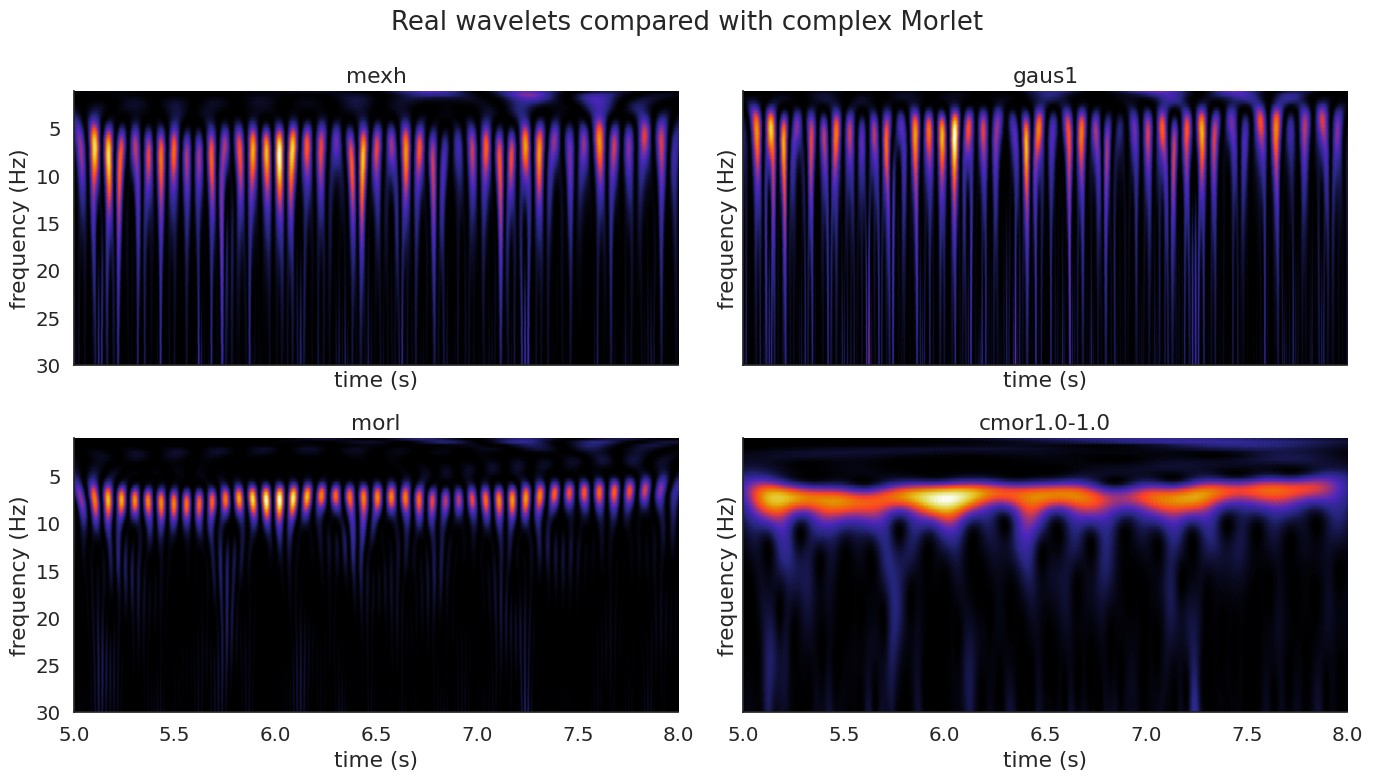

In [33]:
start = 5
stop = 8
sig = moving_lfp[int(start * moving_sr):int(stop * moving_sr)]
sig = sig - np.mean(sig)

freqs_hz = np.linspace(1, 30, 80)

def wavelet_spectrogram(signal, sampling_rate, freqs_hz, wavelet):
    normalized_freqs = freqs_hz / sampling_rate
    scales = scale2frequency(wavelet, normalized_freqs)
    coefficients, _ = cwt(signal, wavelet=wavelet, scales=scales,
                          sampling_period=1.0 / sampling_rate)
    return np.abs(coefficients) ** 2

wavelets = ["mexh", "gaus1", "morl", "cmor1.0-1.0"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True, sharey=True)
for ax, wavelet in zip(axes.flat, wavelets):
    spec = wavelet_spectrogram(sig, moving_sr, freqs_hz, wavelet)
    ax.imshow(spec, extent=[start, stop, freqs_hz[-1], freqs_hz[0]],
              aspect="auto", cmap="CMRmap")
    ax.set_title(wavelet)
    ax.set_xlabel("time (s)")
    ax.set_ylabel("frequency (Hz)")

plt.suptitle("Real wavelets compared with complex Morlet")
plt.tight_layout()

### Exercise 2 comments

The real wavelets detect local structure, but their spectrograms look less smooth and less directly interpretable as oscillatory power than the complex Morlet result. They are smeared along frequency axis, which is a natural trade-off of temporal fitlering. The Mexican hat and Gaussian wavelets are good at detecting local bumps or changes in the signal, so they emphasize sharp events and broad structures. The real Morlet is closer to a complex Morlet because it is oscillatory, but it still lacks the imaginary part.

The complex Morlet gives a cleaner power estimate because the complex coefficients contain phase information. Taking the magnitude of a complex wavelet coefficient is a more stable way to estimate amplitude/power invaraint to phase differences. With real wavelets, the response can depend more on whether the wavelet is aligned with the positive or negative phase of the signal.

## Exercise 3 solution

For REM detection I compute theta-band and delta-band instantaneous power. Then, z-score both power traces and threshold the difference between them.

Detected REM: 39.0% of the session at threshold 0.2
Detected nREM: 61.0% of the session at threshold 0.2


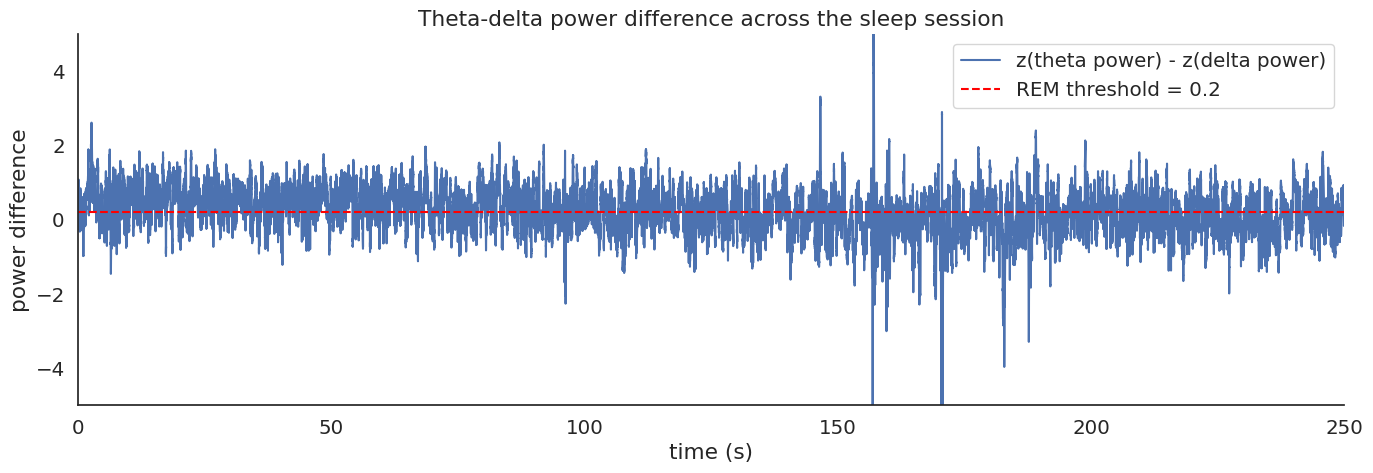

In [ ]:
theta_power = lf.power(sleep_lfp, 6, 10, sampling_rate=sleep_sr, n_freqs=20)
delta_power = lf.power(sleep_lfp, 2, 4, sampling_rate=sleep_sr, n_freqs=20)

theta_z = zscore(theta_power)
delta_z = zscore(delta_power)
power_difference = theta_z - delta_z
time_s = np.arange(len(power_difference)) / sleep_sr

threshold = 0.2
rem_mask = power_difference > threshold
nrem_mask = power_difference < threshold

plt.figure(figsize=(14, 5))
plt.plot(time_s, power_difference, label="z(theta power) - z(delta power)")
plt.axhline(threshold, color="red", linestyle="--", label=f"REM threshold = {threshold}")
plt.xlim(0,250)
plt.ylim(-5,5)
plt.xlabel("time (s)")
plt.ylabel("power delta")
plt.title("Theta-delta power difference across the sleep session")
plt.legend()
plt.tight_layout()

rem_fraction = rem_mask.mean()
print(f"Detected REM: {rem_fraction * 100:.1f}% of the session at threshold {threshold}")
print(f"Detected nREM: {(1 - rem_fraction) * 100:.1f}% of the session at threshold {threshold}")

No REM segment reached 2.0 s; using the longest one (1.55 s).


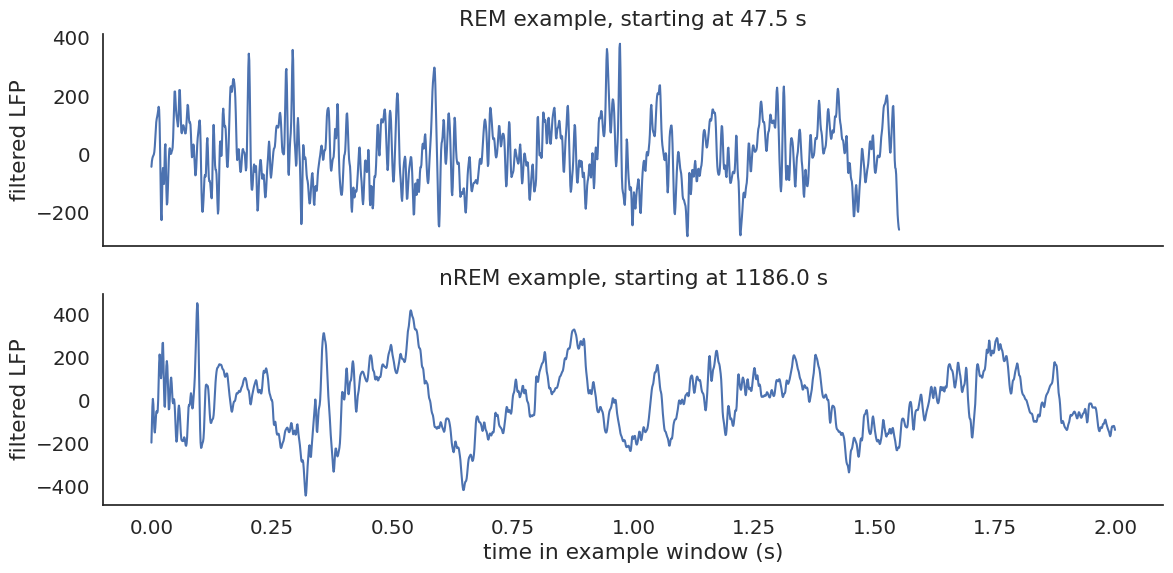

In [35]:
def contiguous_segments(mask):
    """Return start and stop indices for contiguous True regions."""
    mask = np.asarray(mask, dtype=bool)
    changes = np.diff(mask.astype(int))
    starts = list(np.where(changes == 1)[0] + 1)
    stops = list(np.where(changes == -1)[0] + 1)
    if mask[0]:
        starts = [0] + starts
    if mask[-1]:
        stops = stops + [len(mask)]
    return list(zip(starts, stops))

def segment_for_plot(mask, desired_seconds, sampling_rate, label):
    desired_len = int(desired_seconds * sampling_rate)
    segments = contiguous_segments(mask)
    if not segments:
        raise ValueError(f"No {label} samples were detected at this threshold")

    for start_idx, stop_idx in segments:
        if stop_idx - start_idx >= desired_len:
            return start_idx, desired_len

    start_idx, stop_idx = max(segments, key=lambda segment: segment[1] - segment[0])
    actual_len = stop_idx - start_idx
    actual_seconds = actual_len / sampling_rate
    print(f"No {label} segment reached {desired_seconds:.1f} s; using the longest one ({actual_seconds:.2f} s).")
    return start_idx, actual_len

wideband_sleep = lf.bandpass_filter(sleep_lfp, 1, 200, sampling_rate=sleep_sr, filter_order=5)

window_seconds = 2
rem_start, rem_samples = segment_for_plot(rem_mask, desired_seconds=window_seconds,
                                         sampling_rate=sleep_sr, label="REM")
nrem_start, nrem_samples = segment_for_plot(nrem_mask, desired_seconds=window_seconds,
                                           sampling_rate=sleep_sr, label="nREM")

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, label, start_idx, n_samples in [
    (axes[0], "REM example", rem_start, rem_samples),
    (axes[1], "nREM example", nrem_start, nrem_samples),
]:
    stop_idx = start_idx + n_samples
    local_time = np.arange(n_samples) / sleep_sr
    ax.plot(local_time, wideband_sleep[start_idx:stop_idx])
    ax.set_title(f"{label}, starting at {start_idx / sleep_sr:.1f} s")
    ax.set_ylabel("filtered LFP")

axes[-1].set_xlabel("time in example window (s)")
plt.tight_layout()

threshold  0.0:  49.8% REM
threshold  0.2:  39.0% REM
threshold  0.5:  24.9% REM
threshold  1.0:  10.2% REM


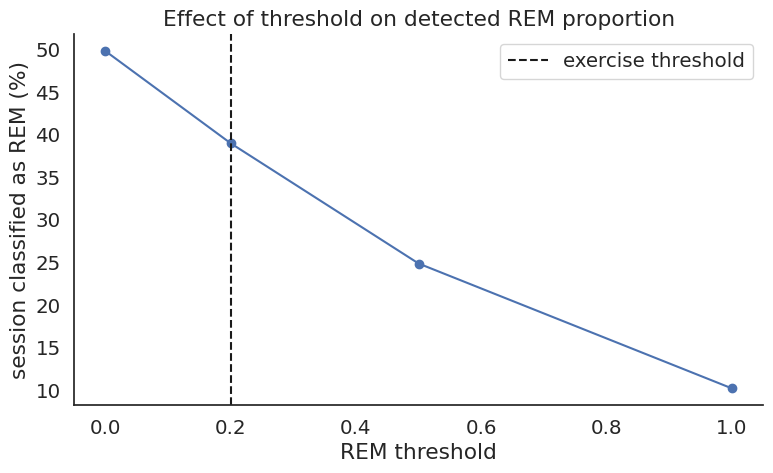

In [41]:
thresholds = np.array([0.0, 0.2, 0.5, 1.0])
rem_percent = [100 * np.mean(power_difference > th) for th in thresholds]

plt.figure(figsize=(8, 5))
plt.plot(thresholds, rem_percent, marker="o")
plt.axvline(0.2, color="k", linestyle="--", label="exercise threshold")
plt.xlabel("REM threshold")
plt.ylabel("session classified as REM (%)")
plt.title("Effect of threshold on detected REM proportion")
plt.legend()
plt.tight_layout()

for th, pct in zip(thresholds, rem_percent):
    print(f"threshold {th:>4.1f}: {pct:>5.1f}% REM")

### Exercise 3 comments

The theta-delta difference gives a simple sleep-state score. Positive values mean theta power is stronger than delta power after normalization, which is the expected pattern during REM. Negative or low values mean delta dominates more, which is consistent with nREM.

The threshold has a large effect on the amount of detected REM. Lowering the threshold labels more of the recording as REM, including ambiguous periods. Raising the threshold makes the detector stricter and keeps only periods with clearly stronger theta than delta. The threshold of 0.2 is therefore to be placed under scrutiny.